# Описательный анализ (EDA): Т-001, Обследование рабочей силы, 2021–2024

**Что это за данные.** Четыре CSV (`2021.csv`…`2024.csv`, ~40 МБ, ~470 тыс. строк каждый) — это **микроданные на уровне респондента**, а не агрегаты. Значения — числовые *коды* ответов анкеты; справочника «код → подпись» в архиве нет (есть только перечень полей и расшифровка аббревиатур). Анкета менялась по годам, поэтому одноимённые колонки **не считаются эквивалентными** без проверки: набор кодов, доля пропусков и распределения сравниваются явно в разделе о связях между годами.

**Соглашения.** Названия колонок не переводятся. Все поля читаются как строки (сохраняем ведущие нули в кодах вроде `06`, `048`), затем поля-количества приводятся к числам. Коды категорий не интерпретируются шире, чем сказано в расшифровке аббревиатур.

In [5]:
import os, io, json, zipfile, glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import openpyxl
from IPython.display import display, Markdown
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_rows', 80, 'display.max_columns', 30, 'display.width', 200, 'display.max_colwidth', 110)

DATA = '/content'
YEARS = [2021, 2022, 2023, 2024]
SAMPLE = int(os.environ.get('NB_SAMPLE', '0')) or None   # для быстрой проверки кода; в финальном прогоне None
STATS = {}

# --- загрузка: всё как строки, пустое = NaN
raw = {y: pd.read_csv(f'{DATA}/{y}.csv', dtype=str, na_values=[''], keep_default_na=False, nrows=SAMPLE) for y in YEARS}
raw_mem = {y: raw[y].memory_usage(deep=True).sum() / 2**20 for y in YEARS}

# --- справочник аббревиатур из архива
zf = zipfile.ZipFile(glob.glob(f'{DATA}/*.zip')[0])
xl = [n for n in zf.namelist() if n.lower().endswith('.xlsx')][0]
ws = openpyxl.load_workbook(io.BytesIO(zf.read(xl))).active
rows = list(ws.iter_rows(values_only=True))
h = [i for i, r in enumerate(rows) if r[0] == 'Аббревиатура'][0]
dic = pd.DataFrame(rows[h+1:], columns=rows[h]).dropna(subset=['Аббревиатура'])
dic = dic[dic['Расшифровка'].notna()]
DESC = dict(zip(dic['Аббревиатура'], dic['Расшифровка']))
UNDOC = [k for k, v in DESC.items() if 'Не найдено' in v or 'не найдено' in v or 'Точного совпадения нет' in v]
print('Размеры (строк × колонок):', {y: raw[y].shape for y in YEARS})
print('Колонок в справочнике:', len(DESC), '| без полноценной расшифровки:', UNDOC)

Размеры (строк × колонок): {2021: (472456, 39), 2022: (467667, 40), 2023: (475635, 40), 2024: (469352, 40)}
Колонок в справочнике: 42 | без полноценной расшифровки: ['PRICH_ZANV', 'vosr', 'mes', 'ORB_OTRASL', 'kv', 'ZAN_PR_ST']


**Выводы.** Файлы одинаковой структуры (≈470 тыс. строк, 39–40 колонок); справочник аббревиатур покрывает не все поля — у части колонок (см. список выше) нет расшифровки, их смысл выводится косвенно.

In [6]:
# Приведение типов: количественные -> числа, остальное (коды) -> category
NUM = ['DH_DATROZH_3', 'vosr', 'DH_PROZHIV_0', 'DH_PROZHIV_5', 'ZAN_VREMYA_1', 'ZAN_VREMYA_2', 'ORB_PRODOL_1', 'ORB_PRODOL_2']
KEY = ['TE', 'K', 'RSPD', 'DH_DATROZH_3', 'DH_DATROZH_2', 'DH_POLRESP']   # псевдоключ: уникального ID респондента в данных нет
data, conv_bad = {}, {}
for y in YEARS:
    df = raw[y].copy(); bad = {}
    for c in NUM:
        if c in df:
            x = pd.to_numeric(df[c], errors='coerce'); bad[c] = int((df[c].notna() & x.isna()).sum()); df[c] = x
    for c in df.columns.difference(NUM): df[c] = df[c].astype('category')
    data[y] = df; conv_bad[y] = bad
print('Нечисловые значения в числовых колонках:', {y: sum(v.values()) for y, v in conv_bad.items()})
print('Память до/после типизации, МБ:', {y: (round(raw_mem[y]), round(data[y].memory_usage(deep=True).sum() / 2**20)) for y in YEARS})

Нечисловые значения в числовых колонках: {2021: 38, 2022: 14, 2023: 25, 2024: 10}
Память до/после типизации, МБ: {2021: (810, 44), 2022: (825, 41), 2023: (827, 41), 2024: (815, 41)}


In [7]:
def cramers(a, b):
    ct = pd.crosstab(a, b)
    if ct.shape[0] < 2 or ct.shape[1] < 2: return np.nan
    o = ct.values.astype(float); e = o.sum(1, keepdims=True) * o.sum(0, keepdims=True) / o.sum()
    return float(np.sqrt(((o - e) ** 2 / e).sum() / o.sum() / (min(o.shape) - 1)))

def profile(y):
    df = data[y]; n = len(df); S = {}
    num_c = [c for c in NUM if c in df]; cat_c = [c for c in df.columns if c not in NUM]
    display(Markdown(f'## Датасет {y}'))
    # 1. форма, типы, память
    mem = df.memory_usage(deep=True).sum() / 2**20
    S.update(rows=n, cols=df.shape[1], mem_mb=round(mem, 1), raw_mem_mb=round(raw_mem[y], 1))
    print(f'shape = {df.shape}; память: {mem:.1f} МБ (строками было {raw_mem[y]:.1f} МБ)')
    pas = pd.DataFrame({'dtype': df.dtypes.astype(str), 'уникальных': df.nunique(), '% пропусков': (df.isna().mean() * 100).round(2)})
    pas['расшифровка'] = [str(DESC.get(c, 'нет в справочнике'))[:85] for c in pas.index]
    display(Markdown('**Паспорт колонок**')); display(pas)
    # 2. пропуски
    miss = (df.isna().mean() * 100).sort_values(ascending=False); miss = miss[miss > 0]
    display(Markdown('**Пропуски (только колонки с >0%)**')); display(miss.round(2).to_frame('% пропусков'))
    S['n_cols_na'] = int(len(miss)); S['top_na'] = miss.head(6).round(1).to_dict(); S['cols_na_ge_90'] = miss[miss >= 90].index.tolist()
    # 3. дубликаты
    full = int(df.duplicated().sum()); key = [c for c in KEY if c in df]
    kd = int(df.duplicated(key, keep=False).sum())
    print(f'Полных дубликатов: {full} ({full/n*100:.2f}%). Уникального ID нет; по псевдоключу {key}: строк в группах >1 = {kd} ({kd/n*100:.1f}%)')
    S.update(dup_full=full, dup_full_pct=round(full/n*100, 2), dup_key_rows_pct=round(kd/n*100, 1))
    # 4. числовые
    x = df[num_c]; d = x.describe().T; d['skew'] = x.skew()
    q1, q3 = x.quantile(.25), x.quantile(.75); iqr = q3 - q1
    d['выбросов IQR'] = ((x.lt(q1 - 1.5 * iqr)) | (x.gt(q3 + 1.5 * iqr))).sum()
    d['% выбросов'] = d['выбросов IQR'] / x.notna().sum() * 100
    display(Markdown('**Числовые: describe, асимметрия, выбросы (IQR, только счётчики)**')); display(d.round(2))
    S['outl'] = d['% выбросов'].round(1).to_dict(); S['skew'] = d['skew'].round(2).to_dict()
    S['implaus'] = {'vosr>100': int((x['vosr'] > 100).sum()), 'ZAN_VREMYA_2>168': int((x['ZAN_VREMYA_2'] > 168).sum()) if 'ZAN_VREMYA_2' in x else 0,
                    'ZAN_VREMYA_2==0': int((x['ZAN_VREMYA_2'] == 0).sum())}
    # 5. категориальные
    r = []
    for c in cat_c:
        vc = df[c].astype(object).value_counts(normalize=True)
        r.append((c, df[c].nunique(), '; '.join(f'{k}: {v*100:.1f}%' for k, v in vc.head(5).items())))
    display(Markdown('**Категориальные (коды): число уникальных и топ-5 значений (доля от непустых)**'))
    display(pd.DataFrame(r, columns=['колонка', 'уникальных', 'топ-5']).set_index('колонка'))
    S['high_card'] = {c: int(df[c].nunique()) for c in cat_c if df[c].nunique() > 100}
    # 6. даты
    display(Markdown('**Даты и время**'))
    bm = df['DH_DATROZH_2'].astype(object); ok_m = [f'{i:02d}' for i in range(1, 13)]
    bad_m = int((bm.notna() & ~bm.isin(ok_m)).sum())
    by = df['DH_DATROZH_3']; diff = (y - by - df['vosr'])
    age_ok = diff.isin([0, 1]).mean() * 100
    print(f'Год рождения: {by.min():.0f}–{by.max():.0f}; невалидных месяцев рождения: {bad_m}; пропусков: {by.isna().sum()}')
    print(f'Возраст vosr согласуется с годом рождения (год опроса − год рождения − vosr ∈ {{0,1}}): {age_ok:.1f}% строк; распределение расхождений: {diff.value_counts().head(5).to_dict()}')
    S.update(birth_min=float(by.min()), birth_max=float(by.max()), bad_month=bad_m, age_consistent_pct=round(age_ok, 1))
    if 'mes' in df:
        m = pd.to_numeric(df['mes'].astype(object), errors='coerce'); kvn = pd.to_numeric(df['kv'].astype(object), errors='coerce')
        present = sorted(m.dropna().astype(int).unique()); gaps = sorted(set(range(1, 13)) - set(present))
        kv_ok = (((m - 1) // 3 + 1) == kvn).mean() * 100
        print(f'Время опроса: поле mes (месяц), kv (квартал). Месяцы в данных: {present}; отсутствуют: {gaps or "нет"}; kv согласован с mes: {kv_ok:.1f}%')
        print('Строк по месяцам:', m.value_counts().sort_index().astype(int).to_dict())
        S.update(gran='месяц/квартал', months_missing=gaps, kv_ok=round(kv_ok, 1))
    else:
        print('Полей времени опроса нет (нет mes/kv): гранулярность = год (по имени файла). Динамика внутри года недоступна.')
        S.update(gran='только год', months_missing='не определимо')
    # 7. корреляции
    display(Markdown('**Корреляции: только пары с |r| > 0.5**'))
    cm = x.corr(); pr = [(a, b, round(cm.loc[a, b], 3)) for i, a in enumerate(cm.columns) for b in cm.columns[i+1:] if abs(cm.loc[a, b]) > .5]
    display(pd.DataFrame(pr, columns=['a', 'b', 'Pearson r']).sort_values('Pearson r', key=abs, ascending=False) if pr else 'Числовых пар с |r|>0.5 нет')
    s = df.sample(min(n, 100000), random_state=0); lowc = [c for c in cat_c if 1 < df[c].nunique() <= 25]
    cv = []
    for i, a in enumerate(lowc):
        for b in lowc[i+1:]:
            v = cramers(s[a].astype(object), s[b].astype(object))
            if v > .5: cv.append((a, b, round(v, 3)))
    cvd = pd.DataFrame(cv, columns=['a', 'b', 'Cramér V']).sort_values('Cramér V', ascending=False)
    print('Категориальные пары (Cramér V > 0.5, выборка 100 тыс.). Часть связей — структурная (общая логика пропусков/вложенные коды):')
    display(cvd.head(15)); S['pairs_num'] = pr; S['pairs_cat_n'] = len(cv); S['pairs_cat_top'] = cv[:0] + cvd.head(5).values.tolist()
    # 8. графики (5)
    fig, ax = plt.subplots(2, 3, figsize=(18, 9)); ax = ax.ravel(); ax[5].axis('off')
    mm = miss.head(12)
    ax[0].barh(mm.index[::-1], mm.values[::-1], color='#c0504d'); ax[0].set_title('Пропуски, % (топ-12 колонок)'); ax[0].set_xlim(0, 100)
    ax[1].hist(df['vosr'].dropna(), bins=np.arange(0, 105, 2), color='#4f81bd'); ax[1].set_title('vosr: распределение'); ax[1].set_xlabel('vosr')
    hh = df['ZAN_VREMYA_2'].dropna(); ax[2].hist(hh[hh <= 100], bins=50, color='#9bbb59'); ax[2].set_title(f'ZAN_VREMYA_2 (≤100; всего непустых {len(hh):,})'.replace(',', ' '))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax[3], cbar=False, annot_kws={'size': 7}); ax[3].set_title('Корреляции числовых полей'); ax[3].tick_params(labelsize=7)
    emp = (df['ZAN_RABOTA'].astype(object) == '1')
    if 'mes' in df:
        g = pd.DataFrame({'m': pd.to_numeric(df['mes'].astype(object), errors='coerce'), 'e': emp}).groupby('m')
        ax[4].bar(g.size().index, g.size().values, color='#8064a2', alpha=.6); ax[4].set_ylabel('строк')
        a2 = ax[4].twinx(); a2.plot(g['e'].mean().index, g['e'].mean().values * 100, 'o-', color='k'); a2.set_ylabel('% ZAN_RABOTA=1'); a2.grid(False)
        ax[4].set_title('Динамика по месяцам опроса'); ax[4].set_xlabel('mes')
    else:
        ag = pd.cut(df['vosr'], [0, 15, 20, 25, 30, 40, 50, 60, 70, 120]); gg = emp.groupby(ag).mean() * 100
        ax[4].bar(range(len(gg)), gg.values, color='#8064a2'); ax[4].set_xticks(range(len(gg))); ax[4].set_xticklabels([str(i) for i in gg.index], rotation=45, fontsize=7)
        ax[4].set_title('Нет поля времени → % ZAN_RABOTA=1 по возрасту')
    fig.suptitle(f'Датасет {y}', fontsize=14); plt.tight_layout(); plt.show()
    STATS[y] = S

## Датасет 2021

shape = (472456, 39); память: 43.8 МБ (строками было 810.1 МБ)


**Паспорт колонок**

,dtype,уникальных,% пропусков,расшифровка
DH_DATROZH_2,category,12,0.00,Дата рождения — месяц
DH_DATROZH_3,int64,89,0.00,Дата рождения — год
DH_GLROSTV,category,9,0.00,Глава домохозяйства (родство/статус)
DH_OBRAZOV,category,8,0.00,Образование (уровень образования респондента)
DH_POLRESP,category,2,0.00,Пол респондента
DH_PROZHIV_0,float64,17,53.09,Число проживающих в домохозяйстве — всего человек
DH_PROZHIV_5,float64,10,53.97,Число проживающих в домохозяйстве — возрастная группа 16-72
DH_SEMSOST,category,4,0.00,Семейное состояние / состав семьи
DOP_RABOTA,category,2,32.36,(основной) — наличие дополнительной работы
DRB_PKHDHL,category,5,97.30,(доп. работа) — признак ПХДХ (личное подсобное хозяйство) на дополнительной работе


**Пропуски (только колонки с >0%)**

...

Год рождения: 1915–2006; невалидных месяцев рождения: 0; пропусков: 0
Возраст vosr согласуется с годом рождения (год опроса − год рождения − vosr ∈ {0,1}): 99.9% строк; распределение расхождений: {0: 243508, 1: 228601, -1: 111, 2: 88, -2: 22}
Полей времени опроса нет (нет mes/kv): гранулярность = год (по имени файла). Динамика внутри года недоступна.


**Корреляции: только пары с |r| > 0.5**

,a,b,Pearson r
0,DH_DATROZH_3,vosr,-1.000
3,ZAN_VREMYA_2,ORB_PRODOL_2,0.966
2,ZAN_VREMYA_1,ORB_PRODOL_1,0.916
1,DH_PROZHIV_0,DH_PROZHIV_5,0.678


Категориальные пары (Cramér V > 0.5, выборка 100 тыс.). Часть связей — структурная (общая логика пропусков/вложенные коды):


,a,b,Cramér V
2,DRB_PKHDHL,ZAN_RBLPDU,1.000
12,PR_NEPOISK,ZAN_RABOTA,0.991
9,ORB_PKHDHL,ORB_STATUS,0.883
10,ORB_PKHDHL,ZAN_RBLPDU,0.875
7,ORB_MESTOR,ZAN_RBLPDU,0.875
11,ORB_STATUS,ZAN_RBLPDU,0.875
0,DOP_RABOTA,LP_POTREBL,0.710
1,DOP_RABOTA,PR_NEPOISK,0.644
6,ORB_MESTOR,ORB_PKHDHL,0.613
8,ORB_OTRASL,ZAN_RBLPDU,0.584


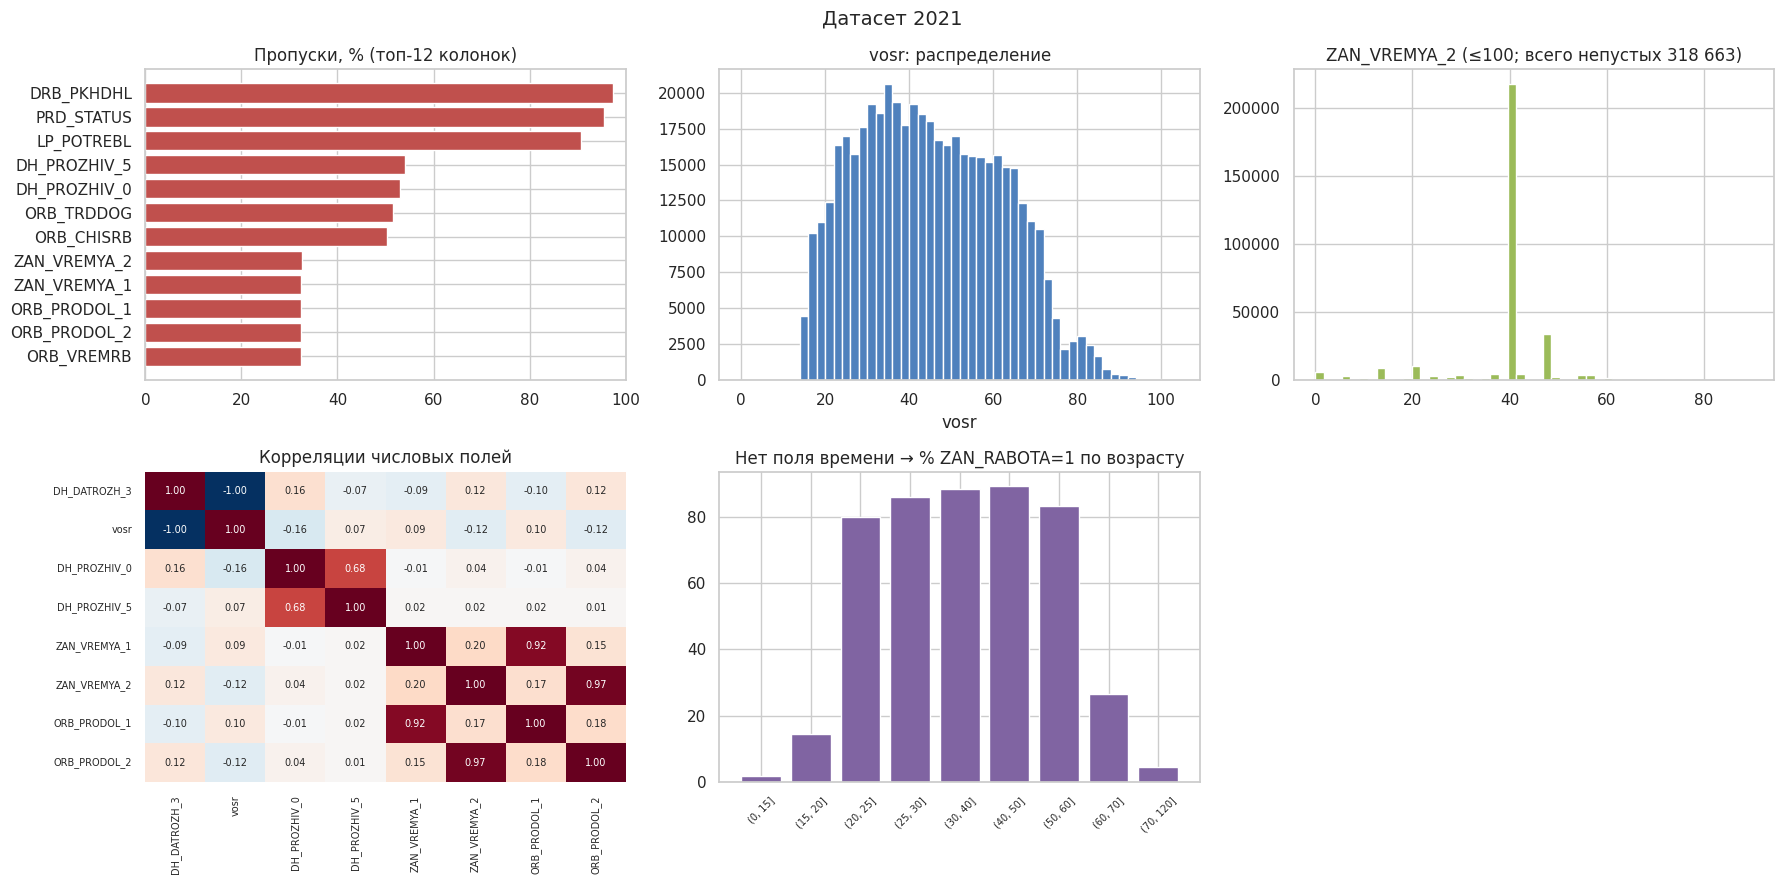

In [8]:
profile(2021)

**Выводы 2021.** 472 456 × 39; после типизации 810 → 44 МБ. Полных дубликатов 1,27 % (5 993) — на порядок больше, чем в 2022–2024 (0,14 %). Поля времени опроса нет (только год); три колонки пусты на >90 % (`DRB_PKHDHL`, `PRD_STATUS`, `LP_POTREBL`) — вероятно, skip-логика анкеты. Возраст `vosr` согласован с годом рождения в 99,9 % строк.

## Датасет 2022

shape = (467667, 40); память: 40.7 МБ (строками было 824.6 МБ)


**Паспорт колонок**

,dtype,уникальных,% пропусков,расшифровка
DH_DATROZH_2,category,12,0.00,Дата рождения — месяц
DH_DATROZH_3,int64,88,0.00,Дата рождения — год
DH_GLROSTV,category,9,0.00,Глава домохозяйства (родство/статус)
DH_OBRAZOV,category,9,0.00,Образование (уровень образования респондента)
DH_POLRESP,category,2,0.00,Пол респондента
DH_PROZHIV_0,float64,15,52.03,Число проживающих в домохозяйстве — всего человек
DH_SEMSOST,category,4,0.00,Семейное состояние / состав семьи
DOP_RABOTA,category,2,32.82,(основной) — наличие дополнительной работы
DRB_PKHDHL,category,6,97.85,(доп. работа) — признак ПХДХ (личное подсобное хозяйство) на дополнительной работе
Im_li_d,category,2,0.00,Имеются ли дети (в домохозяйстве)


**Пропуски (только колонки с >0%)**

...

Год рождения: 1906–2007; невалидных месяцев рождения: 0; пропусков: 0
Возраст vosr согласуется с годом рождения (год опроса − год рождения − vosr ∈ {0,1}): 99.9% строк; распределение расхождений: {0: 243354, 1: 224078, -1: 92, 2: 64, 3: 14}
Время опроса: поле mes (месяц), kv (квартал). Месяцы в данных: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]; отсутствуют: нет; kv согласован с mes: 93.4%
Строк по месяцам: {1: 38613, 2: 38180, 3: 37822, 4: 38976, 5: 39547, 6: 40065, 7: 39583, 8: 39779, 9: 39060, 10: 39338, 11: 38566, 12: 38138}


**Корреляции: только пары с |r| > 0.5**

,a,b,Pearson r
0,DH_DATROZH_3,vosr,-1.000
2,ZAN_VREMYA_2,ORB_PRODOL_2,0.970
1,ZAN_VREMYA_1,ORB_PRODOL_1,0.931


Категориальные пары (Cramér V > 0.5, выборка 100 тыс.). Часть связей — структурная (общая логика пропусков/вложенные коды):


,a,b,Cramér V
10,PR_NEPOISK,ZAN_RABOTA,0.997
3,DRB_PKHDHL,ZAN_RBLPDU,0.992
11,kv,mes,0.930
8,ORB_PKHDHL,ZAN_RBLPDU,0.910
9,ORB_STATUS,ZAN_RBLPDU,0.910
5,ORB_MESTOR,ZAN_RBLPDU,0.909
7,ORB_PKHDHL,ORB_STATUS,0.884
0,DOP_RABOTA,LP_POTREBL,0.725
1,DRB_PKHDHL,PRICH_ZANV,0.632
4,ORB_MESTOR,ORB_PKHDHL,0.598


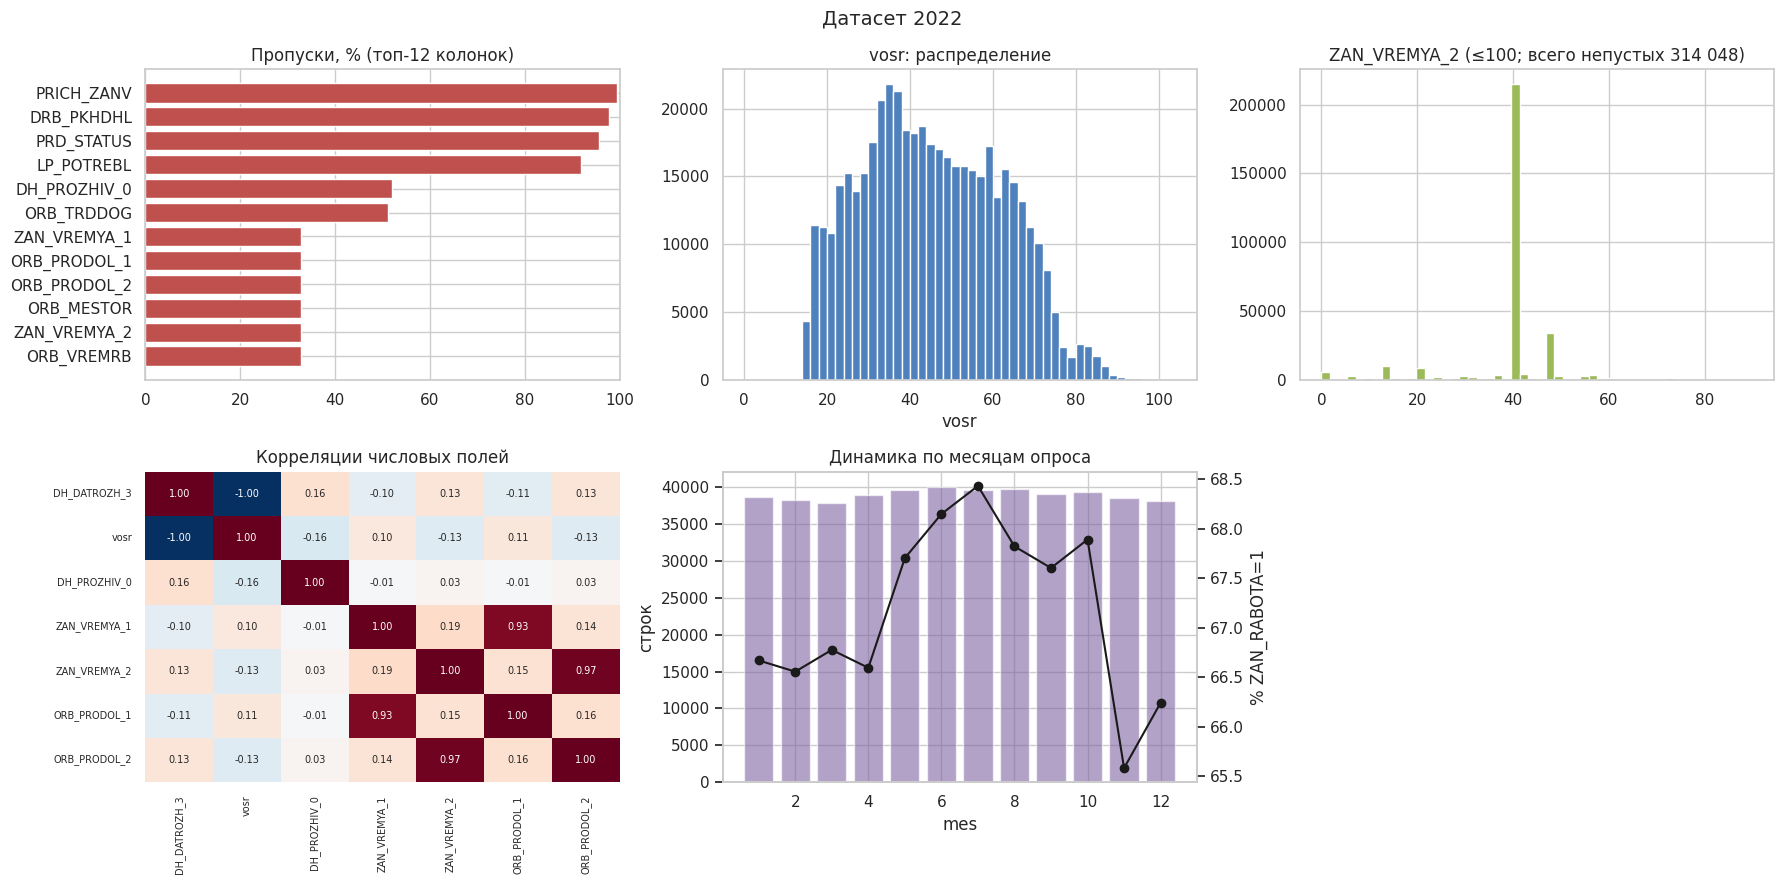

In [9]:
profile(2022)

**Выводы 2022.** 467 667 × 40; добавились `mes`, `kv` (все 12 месяцев, `kv` согласован с `mes`) и `PRICH_ZANV` (99,4 % пропусков), исчезли `DH_PROZHIV_5` и `ORB_CHISRB`. Числовые часы (`ZAN_VREMYA_2`, `ORB_PRODOL_2`) дают ~30 % «выбросов» по IQR — это не ошибки, а компактное распределение около 40 ч и нули (5,4 тыс. строк `ZAN_VREMYA_2 = 0` — смысл нужно уточнить).

## Датасет 2023

shape = (475635, 40); память: 41.4 МБ (строками было 826.9 МБ)


**Паспорт колонок**

,dtype,уникальных,% пропусков,расшифровка
DH_DATROZH_2,category,12,0.00,Дата рождения — месяц
DH_DATROZH_3,int64,87,0.00,Дата рождения — год
DH_GLROSTV,category,9,0.00,Глава домохозяйства (родство/статус)
DH_OBRAZOV,category,9,0.00,Образование (уровень образования респондента)
DH_POLRESP,category,2,0.00,Пол респондента
DH_PROZHIV_0,float64,15,52.17,Число проживающих в домохозяйстве — всего человек
DH_SEMSOST,category,4,0.00,Семейное состояние / состав семьи
DOP_RABOTA,category,2,68.98,(основной) — наличие дополнительной работы
DRB_PKHDHL,category,6,99.49,(доп. работа) — признак ПХДХ (личное подсобное хозяйство) на дополнительной работе
Im_li_d,category,2,0.00,Имеются ли дети (в домохозяйстве)


**Пропуски (только колонки с >0%)**

...

Год рождения: 1922–2008; невалидных месяцев рождения: 0; пропусков: 0
Возраст vosr согласуется с годом рождения (год опроса − год рождения − vosr ∈ {0,1}): 99.9% строк; распределение расхождений: {0: 269377, 1: 205985, -1: 95, 20: 62, 2: 45}
Время опроса: поле mes (месяц), kv (квартал). Месяцы в данных: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]; отсутствуют: нет; kv согласован с mes: 93.7%
Строк по месяцам: {1: 38661, 2: 40092, 3: 39069, 4: 39464, 5: 39119, 6: 40363, 7: 39565, 8: 40467, 9: 40543, 10: 40648, 11: 37897, 12: 39747}


**Корреляции: только пары с |r| > 0.5**

,a,b,Pearson r
0,DH_DATROZH_3,vosr,-0.999
2,ZAN_VREMYA_2,ORB_PRODOL_2,0.970
1,ZAN_VREMYA_1,ORB_PRODOL_1,0.932


Категориальные пары (Cramér V > 0.5, выборка 100 тыс.). Часть связей — структурная (общая логика пропусков/вложенные коды):


,a,b,Cramér V
14,PR_NEPOISK,ZAN_RABOTA,0.999
3,DRB_PKHDHL,ZAN_RBLPDU,0.952
15,kv,mes,0.936
10,ORB_PKHDHL,ORB_STATUS,0.886
8,ORB_MESTOR,ZAN_RBLPDU,0.885
12,ORB_STATUS,ZAN_RBLPDU,0.885
11,ORB_PKHDHL,ZAN_RBLPDU,0.885
1,DRB_PKHDHL,PRICH_ZANV,0.707
13,PRD_STATUS,PRICH_ZANV,0.612
7,ORB_MESTOR,ORB_PKHDHL,0.604


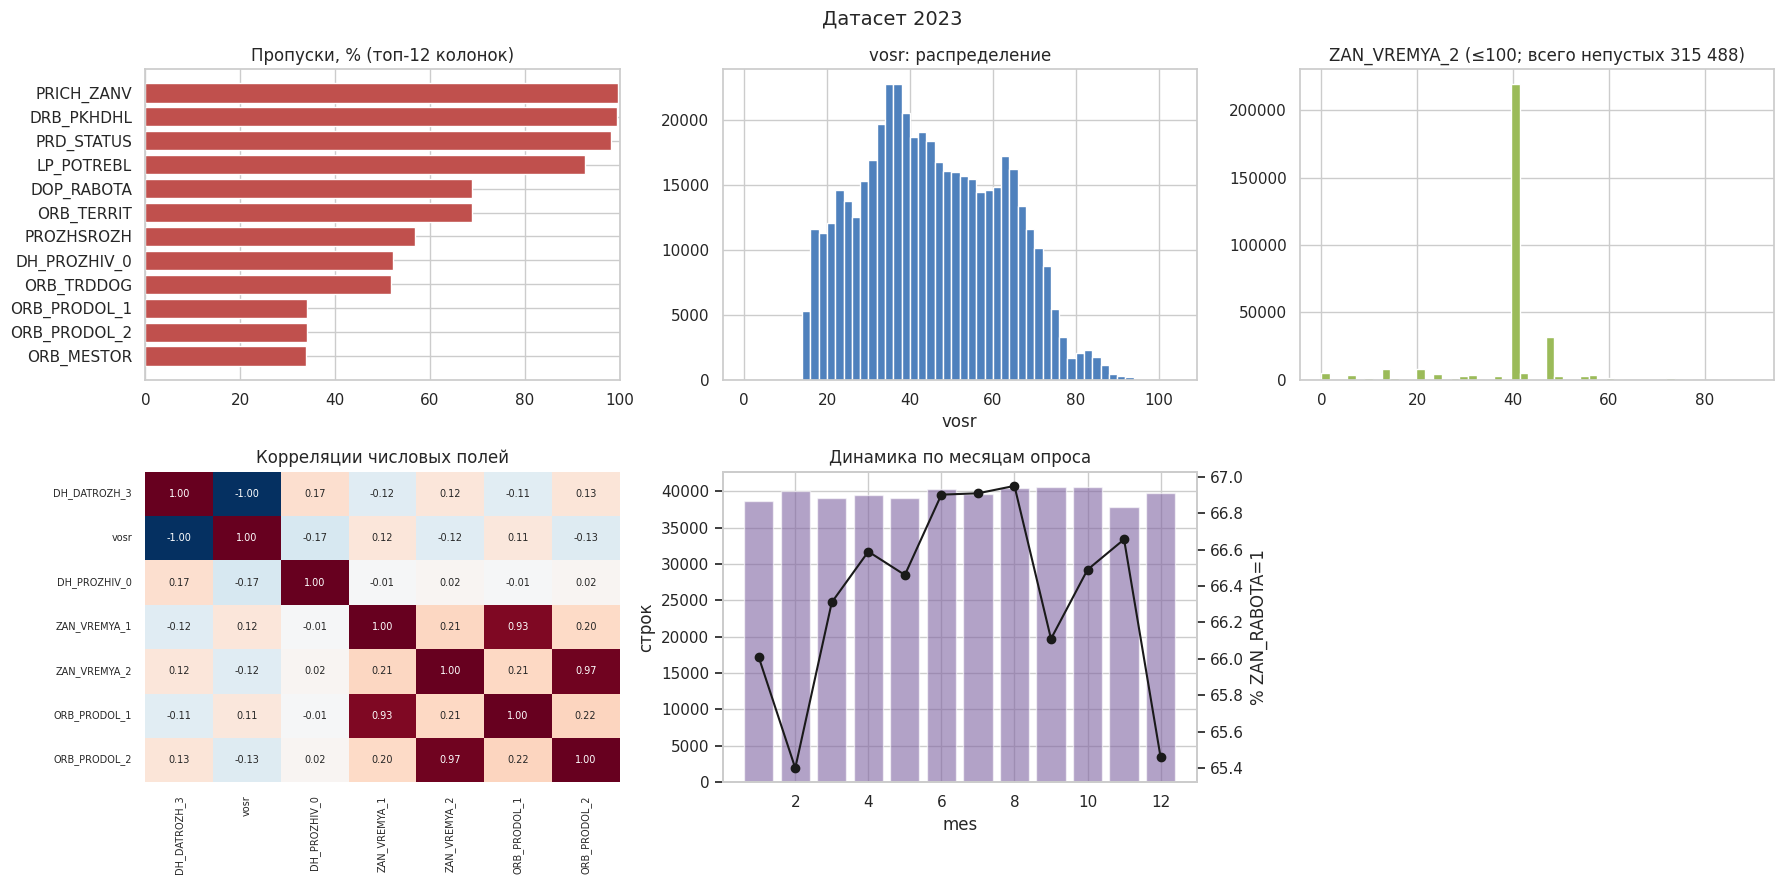

In [10]:
profile(2023)

**Выводы 2023.** 475 635 × 40. Резкий скачок пропусков относительно 2022: `DOP_RABOTA` 33 → 69 %, `ORB_TERRIT` 33 → 69 %, `PROZHSROZH` 0 → 57 % — изменилась логика заполнения вопросов, а не население. Дубликаты на прежнем уровне (0,14 %).

## Датасет 2024

shape = (469352, 40); память: 40.8 МБ (строками было 815.2 МБ)


**Паспорт колонок**

,dtype,уникальных,% пропусков,расшифровка
DH_DATROZH_2,category,12,0.00,Дата рождения — месяц
DH_DATROZH_3,int64,87,0.00,Дата рождения — год
DH_GLROSTV,category,9,0.00,Глава домохозяйства (родство/статус)
DH_OBRAZOV,category,9,0.00,Образование (уровень образования респондента)
DH_POLRESP,category,2,0.00,Пол респондента
DH_PROZHIV_0,float64,16,51.98,Число проживающих в домохозяйстве — всего человек
DH_SEMSOST,category,4,0.00,Семейное состояние / состав семьи
DOP_RABOTA,category,2,71.57,(основной) — наличие дополнительной работы
DRB_PKHDHL,category,6,99.45,(доп. работа) — признак ПХДХ (личное подсобное хозяйство) на дополнительной работе
Im_li_d,category,2,0.00,Имеются ли дети (в домохозяйстве)


**Пропуски (только колонки с >0%)**

...

Год рождения: 1923–2009; невалидных месяцев рождения: 0; пропусков: 0
Возраст vosr согласуется с годом рождения (год опроса − год рождения − vosr ∈ {0,1}): 100.0% строк; распределение расхождений: {0: 267195, 1: 201989, -1: 56, 2: 39, 3: 19}
Время опроса: поле mes (месяц), kv (квартал). Месяцы в данных: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]; отсутствуют: нет; kv согласован с mes: 93.2%
Строк по месяцам: {1: 38877, 2: 39039, 3: 38906, 4: 39732, 5: 40066, 6: 39629, 7: 40185, 8: 39504, 9: 37771, 10: 39196, 11: 38386, 12: 38061}


**Корреляции: только пары с |r| > 0.5**

,a,b,Pearson r
0,DH_DATROZH_3,vosr,-1.000
2,ZAN_VREMYA_2,ORB_PRODOL_2,0.963
1,ZAN_VREMYA_1,ORB_PRODOL_1,0.928


Категориальные пары (Cramér V > 0.5, выборка 100 тыс.). Часть связей — структурная (общая логика пропусков/вложенные коды):


,a,b,Cramér V
18,PR_NEPOISK,ZAN_RABOTA,1.000
17,ORB_TRDDOG,PRD_STATUS,1.000
19,kv,mes,0.931
10,ORB_PKHDHL,ORB_STATUS,0.891
13,ORB_PKHDHL,ZAN_RBLPDU,0.873
7,ORB_MESTOR,ZAN_RBLPDU,0.872
16,ORB_STATUS,ZAN_RBLPDU,0.872
11,ORB_PKHDHL,ORB_TRDDOG,0.726
0,DRB_PKHDHL,LP_POTREBL,0.626
12,ORB_PKHDHL,PRD_STATUS,0.624


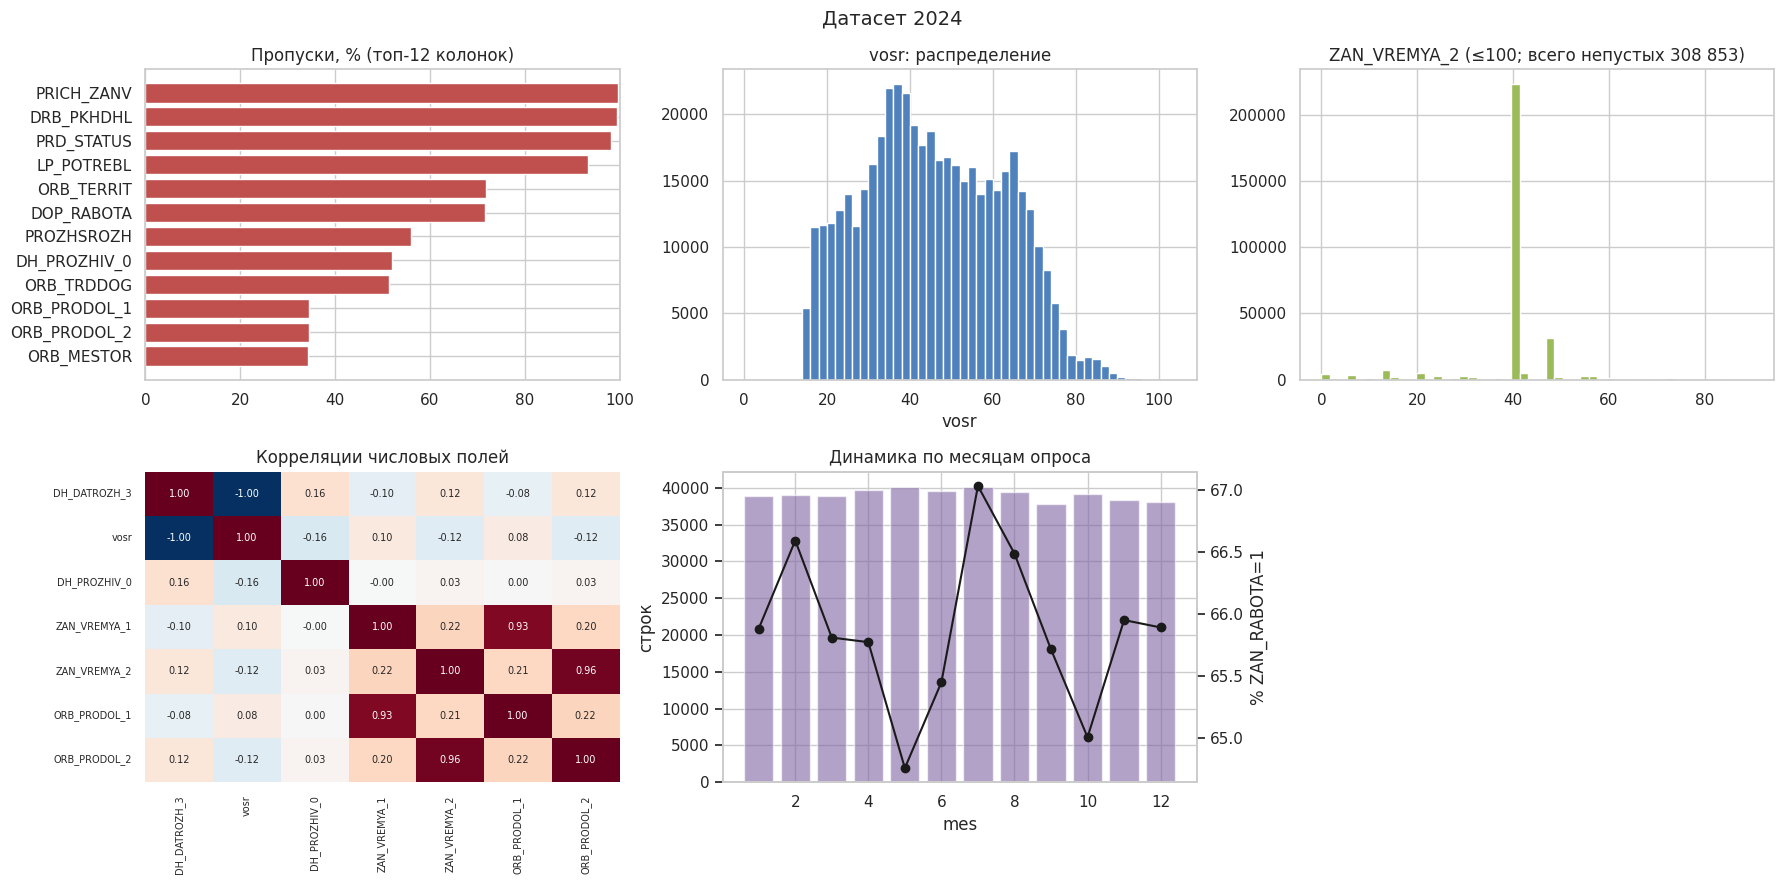

In [11]:
profile(2024)

**Выводы 2024.** 469 352 × 40; структура как в 2023. Доля `ZAN_RABOTA=1` продолжает снижаться (65,9 %). Сильные категориальные связи (например, `PR_NEPOISK`↔`ZAN_RABOTA`, `ORB_TRDDOG`↔`PRD_STATUS`, V≈1) — структурные, следствие взаимоисключающих групп респондентов, а не «находки».

## Связи между датасетами (2021–2024)

In [12]:
allc = sorted(set().union(*[set(data[y].columns) for y in YEARS]))
pres = pd.DataFrame({y: {c: c in data[y].columns for c in allc} for y in YEARS})
common = pres.index[pres.all(axis=1)].tolist()
display(Markdown(f'**Общих колонок для всех 4 лет: {len(common)} из {len(allc)}. Колонки, присутствующие не во всех годах:**'))
display(pres[~pres.all(axis=1)].replace({True: '✓', False: '—'}))

# --- общие ключи/справочные коды
display(Markdown('**Наборы значений служебных ключей по годам**'))
for c in ['TE', 'K', 'RSPD']:
    sets = {y: set(data[y][c].dropna().astype(str)) for y in YEARS}
    print(c, {y: len(v) for y, v in sets.items()}, '| в 2022–2024 нет в 2021:', sorted(sets[2022] - sets[2021]), '| только в 2021:', sorted(sets[2021] - sets[2022]))

# --- покрытие join'а по псевдоключу (уникального ID нет) + базовая линия «случайного совпадения»
KEYP = KEY
def hkey(df): return pd.util.hash_pandas_object(df[KEYP].astype(str), index=False)
cov = []
for a, b in zip(YEARS[:-1], YEARS[1:]):
    ha = hkey(data[a]); nb = data[b].copy(); hb = set(hkey(nb))
    nb['DH_DATROZH_3'] = nb['DH_DATROZH_3'].sample(frac=1, random_state=0).values; hbase = set(hkey(nb))
    cov.append((f'{a}→{b}', ha.isin(hb).mean() * 100, ha.isin(hbase).mean() * 100))
covd = pd.DataFrame(cov, columns=['пара', '% строк с совпадением ключа', '% при случайной перестановке года рождения']).set_index('пара')
display(Markdown(f'**Покрытие join по псевдоключу {KEYP}** (реального ID респондента нет)')); display(covd.round(1))
STATS['cov'] = covd.round(1).to_dict('index'); STATS['common'] = len(common); STATS['allc'] = len(allc)

**Общих колонок для всех 4 лет: 37 из 42. Колонки, присутствующие не во всех годах:**

,2021,2022,2023,2024
DH_PROZHIV_5,✓,—,—,—
ORB_CHISRB,✓,—,—,—
PRICH_ZANV,—,✓,✓,✓
kv,—,✓,✓,✓
mes,—,✓,✓,✓


**Наборы значений служебных ключей по годам**

TE {2021: 17, 2022: 20, 2023: 20, 2024: 20} | в 2022–2024 нет в 2021: ['10', '33', '62'] | только в 2021: []
K {2021: 2, 2022: 2, 2023: 2, 2024: 2} | в 2022–2024 нет в 2021: [] | только в 2021: []
RSPD {2021: 11, 2022: 9, 2023: 9, 2024: 9} | в 2022–2024 нет в 2021: [] | только в 2021: ['10', '12']


**Покрытие join по псевдоключу ['TE', 'K', 'RSPD', 'DH_DATROZH_3', 'DH_DATROZH_2', 'DH_POLRESP']** (реального ID респондента нет)

,% строк с совпадением ключа,% при случайной перестановке года рождения
пара,,
2021→2022,88.0,86.7
2022→2023,87.8,86.4
2023→2024,87.7,86.6


In [13]:
# --- дрейф колонок между годами: пропуски, набор кодов, сдвиг распределения (TV-расстояние)
rows = []
for c in common:
    na = [data[y][c].isna().mean() * 100 for y in YEARS]; nu = [data[y][c].nunique() for y in YEARS]
    tv, chg = [np.nan] * 3, []
    if c not in NUM and max(nu) <= 60:
        tv = []
        for a, b in zip(YEARS[:-1], YEARS[1:]):
            pa = data[a][c].astype(object).value_counts(normalize=True); pb = data[b][c].astype(object).value_counts(normalize=True)
            idx = pa.index.union(pb.index); tv.append(0.5 * np.abs(pa.reindex(idx, fill_value=0) - pb.reindex(idx, fill_value=0)).sum())
            new, lost = set(pb.index) - set(pa.index), set(pa.index) - set(pb.index)
            if new or lost: chg.append(f'{a}→{b}: +{sorted(new)[:3]} −{sorted(lost)[:3]}')
    rows.append(dict(колонка=c, **{f'NA%_{y}': round(v, 1) for y, v in zip(YEARS, na)}, **{f'кодов_{y}': v for y, v in zip(YEARS, nu)},
                     TV_max=round(np.nanmax(tv), 3) if not np.all(np.isnan(tv)) else np.nan, изменения_кодов=' | '.join(chg)[:120],
                     флаг_NA=max(na) - min(na) > 10))
drift = pd.DataFrame(rows).set_index('колонка')
flag = drift[(drift['флаг_NA']) | (drift['изменения_кодов'] != '') | (drift['TV_max'] > 0.10)].sort_values('TV_max', ascending=False)
display(Markdown(f'**Колонки с признаками несопоставимости между годами (скачок NA >10 п.п., смена набора кодов или TV-сдвиг >0.10): {len(flag)} из {len(common)}**'))
display(flag.drop(columns='флаг_NA'))
STATS['drift_flag'] = flag.index.tolist(); STATS['drift_na'] = drift[drift['флаг_NA']].index.tolist()
STATS['drift_tv'] = flag['TV_max'].dropna().head(6).to_dict()

**Колонки с признаками несопоставимости между годами (скачок NA >10 п.п., смена набора кодов или TV-сдвиг >0.10): 10 из 37**

,NA%_2021,NA%_2022,NA%_2023,NA%_2024,кодов_2021,кодов_2022,кодов_2023,кодов_2024,TV_max,изменения_кодов
колонка,,,,,,,,,,
DH_OBRAZOV,0.0,0.0,0.0,0.0,8,9,9,9,0.284,2021→2022: +['9'] −[]
TE,0.0,0.0,0.0,0.0,17,20,20,20,0.117,"2021→2022: +['10', '33', '62'] −[]"
DRB_PKHDHL,97.3,97.9,99.5,99.5,5,6,6,6,0.091,2021→2022: +['5'] −[]
PRD_STATUS,95.5,95.8,98.3,98.2,10,9,9,10,0.031,2021→2022: +[] −['9'] | 2022→2023: +['9'] −['8'] | 2023→2024: +['8'] −[]
ORB_OTRASL,31.7,32.3,33.5,34.0,19,20,19,19,0.025,2021→2022: +['20'] −[] | 2022→2023: +[] −['20']
ORB_TERRIT,32.4,32.8,68.9,71.8,5,5,5,5,0.024,
DOP_RABOTA,32.4,32.8,69.0,71.6,2,2,2,2,0.019,
PROZHSROZH,0.0,0.0,57.0,56.0,2,2,2,2,0.015,
RSPD,0.0,0.0,0.0,0.0,11,9,9,9,0.011,"2021→2022: +[] −['10', '12']"


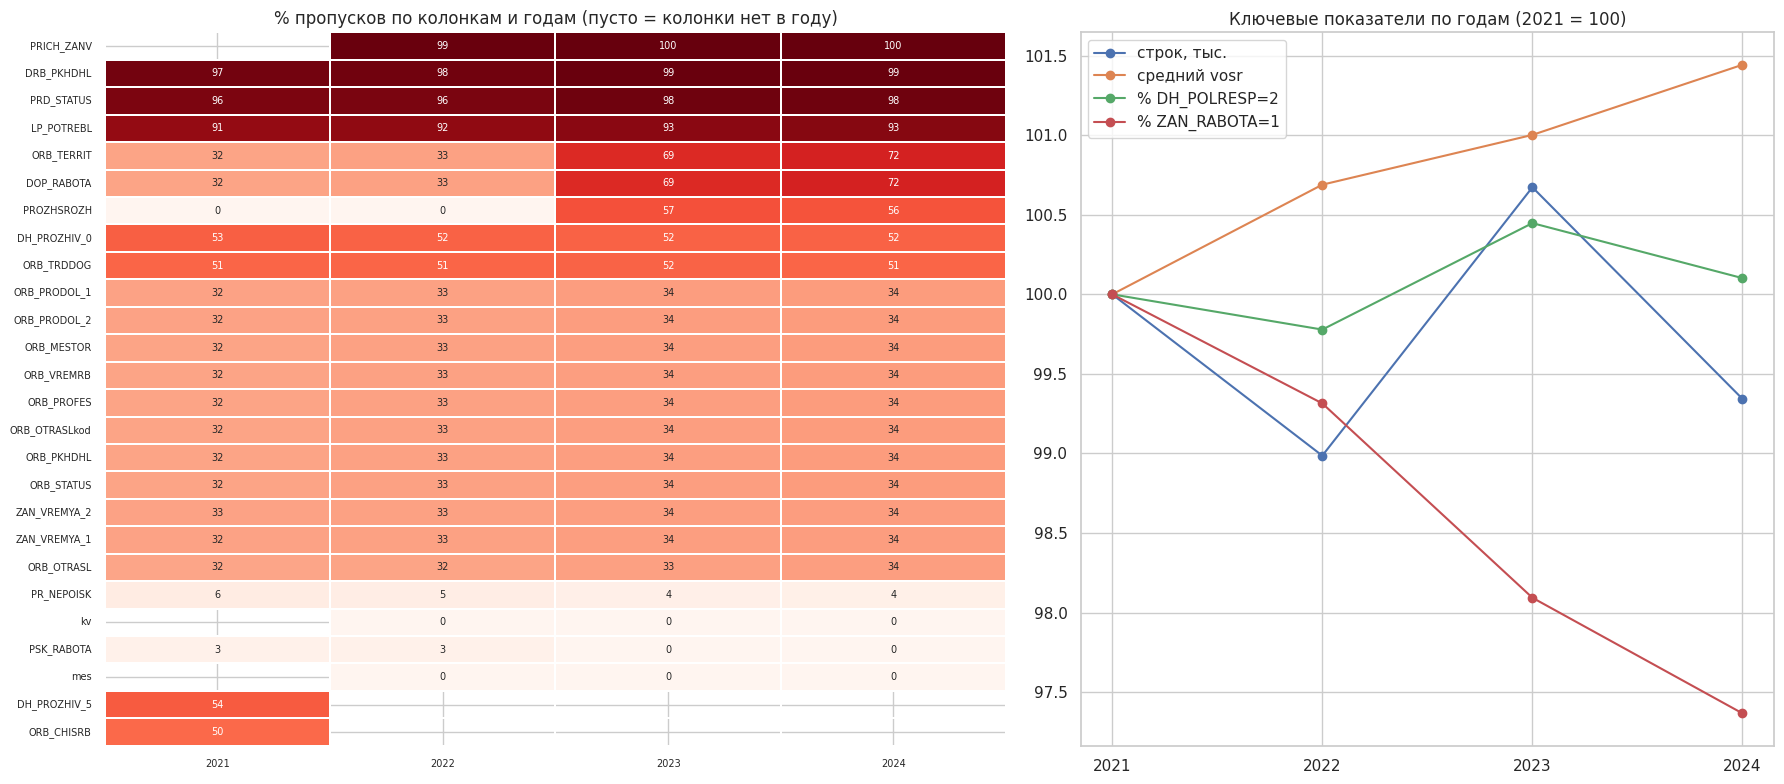

,"строк, тыс.",средний vosr,% DH_POLRESP=2,% ZAN_RABOTA=1
2021,472.46,44.50,53.81,67.64
2022,467.67,44.81,53.69,67.18
2023,475.64,44.95,54.05,66.35
2024,469.35,45.14,53.86,65.86


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1.3, 1]})
na_tab = pd.DataFrame({y: data[y].reindex(columns=allc).isna().mean() * 100 for y in YEARS})
na_tab.loc[~pres.all(axis=1)] = na_tab.loc[~pres.all(axis=1)].where(pres.loc[~pres.all(axis=1)], np.nan)
na_tab = na_tab[(na_tab.fillna(0) > 0).any(axis=1) | ~pres.all(axis=1)].sort_values(2024, ascending=False)
sns.heatmap(na_tab, annot=True, fmt='.0f', cmap='Reds', vmin=0, vmax=100, ax=ax[0], cbar=False, annot_kws={'size': 7}, linewidths=.3, linecolor='w')
ax[0].set_title('% пропусков по колонкам и годам (пусто = колонки нет в году)'); ax[0].tick_params(labelsize=7)
mt = pd.DataFrame({'строк, тыс.': [len(data[y]) / 1000 for y in YEARS], 'средний vosr': [data[y]['vosr'].mean() for y in YEARS],
                   '% DH_POLRESP=2': [(data[y]['DH_POLRESP'].astype(object) == '2').mean() * 100 for y in YEARS],
                   '% ZAN_RABOTA=1': [(data[y]['ZAN_RABOTA'].astype(object) == '1').mean() * 100 for y in YEARS]}, index=YEARS)
z = (mt / mt.iloc[0] * 100); z.plot(marker='o', ax=ax[1]); ax[1].set_title('Ключевые показатели по годам (2021 = 100)'); ax[1].set_xticks(YEARS)
plt.tight_layout(); plt.show(); display(mt.round(2)); STATS['mt'] = mt.round(2).to_dict('index')

**Выводы (между годами).** Сквозного идентификатора респондента нет: `RSPD` — номер человека (9 значений), а совпадение по псевдоключу (~88 %) не отличается от случайной перестановки (~87 %) — **join между годами невозможен, панельный анализ не подтверждается**. Из 42 колонок общих для всех лет — 37; в 10 из них есть признаки несопоставимости (новый код `9` в `DH_OBRAZOV` с 2022 при TV-сдвиге 0,28; `TE` 17 → 20 кодов; скачок пропусков в 2023). Агрегаты по годам можно сравнивать лишь для колонок без флагов.

## Ключевые находки и проблемы качества данных

1. **Это микроданные, не агрегаты:** ~470 тыс. респондентов в год, 4 года, около 1,9 млн строк; уникального ID респондента нет.
2. **Между годами нельзя делать join и панельный анализ:** совпадение по псевдоключу (~88 %) на уровне случайного (~87 %); `RSPD` — лишь номер человека в домохозяйстве.
3. **Смена анкеты видна в данных:** `DH_PROZHIV_5` и `ORB_CHISRB` есть только в 2021; `mes`, `kv`, `PRICH_ZANV` — только с 2022; в 2021 нет времени опроса вообще.
4. **Скачок пропусков в 2023:** `DOP_RABOTA` 33 → 69 %, `ORB_TERRIT` 33 → 69 %, `PROZHSROZH` 0 → 57 % — значения 2021–2022 и 2023–2024 несопоставимы без учёта логики опросника.
5. **Дрейф кодов:** `DH_OBRAZOV` получил код `9` с 2022 (сдвиг распределения TV = 0,28); `TE` 17 → 20 кодов; `RSPD` в 2021 содержит `10`, `12`; у `PRD_STATUS`, `ORB_OTRASL`, `PR_NEPOISK` коды появляются и исчезают по годам.
6. **Файлы структуры не отражают изменений:** документы «2016–2022» и «2022–2024» по тексту идентичны, хотя набор колонок меняется; справочника «код → подпись» нет, часть полей (`vosr`, `mes`, `kv`, `PRICH_ZANV`, `ZAN_PR_ST`) не расшифрована, `ORB_OTRASL` в структуре отсутствует (есть `ORB_OTRASLkod`).
7. **Дубликаты:** полных 1,27 % в 2021 (5 993) против ~0,14 % в 2022–2024; без ID отличить дубли от совпадающих респондентов нельзя.
8. **Структурные пропуски:** 4 колонки пусты на 90–99 % (`PRICH_ZANV`, `DRB_PKHDHL`, `PRD_STATUS`, `LP_POTREBL`), `DH_PROZHIV_0` пуст на ~52 % — при анализе это «вопрос не задавался», а не «нет данных».
9. **Возраст и даты в порядке:** `vosr` согласован с годом рождения в ≥99,9 % строк, месяцы рождения валидны; единичные `vosr > 100` (3–15 в год) — проверить.
10. **`ZAN_VREMYA_2 = 0` (4,5–5,7 тыс. в год)** и ~30 % «выбросов» по IQR — распределение часов не подходит под правило IQR; нули требуют пояснения по анкете.

## Рекомендации для дальнейшей работы

1. Запросить у владельца данных справочник «код → подпись» по годам и актуальные структуры/опросники для 2023–2024; до этого не интерпретировать коды шире расшифровки аббревиатур.
2. Для сопоставления лет строить таблицу соответствия колонок и кодов (crosswalk) и сравнивать только колонки без флагов дрейфа; 2021 и 2022–2024 разделять для `DH_OBRAZOV`, `TE`, `PRD_STATUS`.
3. Не сравнивать напрямую `DOP_RABOTA`, `ORB_TERRIT`, `PROZHSROZH` до/после 2023 без уточнения изменений маршрута вопросов; считать доли от подгруппы, которой вопрос задавался, а не от всех строк.
4. Уточнить, есть ли веса выборки и идентификатор домохозяйства/респондента; без них оценки по населению и панельный анализ некорректны.
5. Дубликаты: сверить с источником, прежде чем удалять (особенно 5 993 в 2021).
6. Для часов работы использовать отдельные правила (0, >84 ч и т.д.) вместо IQR; проверить `vosr > 100`.
7. Дальше: описательные показатели по подгруппам (пол `DH_POLRESP`, возраст, `TE`, месяц/квартал для 2022–2024) отдельно для каждого года; сохранить типизированные данные в parquet (≈40 МБ на год в памяти против 810 МБ строками).

In [15]:
json.dump(STATS, open('/stats.json', 'w'), ensure_ascii=False, default=str)